In [1]:
import copy
import logging
import numpy as np
import pandas as pd
import pyXLMS
from pyXLMS_adaptor import read
from mokapot_rescore import rescore
from post_process import group_by_residue_pair  # noqa: F401
import matplotlib.pyplot as plt

from typing import Optional
from typing import List
from typing import Dict
from typing import Tuple
from typing import Any

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

In [2]:
from IPython.core.magic import register_cell_magic


@register_cell_magic
def skip(line, cell):
    return

In [3]:
%%skip

df = pd.read_csv(
    "../data/THIDDIAXL003_Cas9_PhoX_DIA12_CeleEntrap_100per_LibSizeTest_SN20c4_Report_FM_crosslinking_plusDecoy (Normal).tsv_annotated.csv.xz",
    compression="xz",
    low_memory=False,
)

In [4]:
%%skip

df = group_by_residue_pair(df)
df.to_csv("../data/entrapment_grouped.csv", index=False)

In [5]:
df = pd.read_csv("../data/entrapment_grouped.csv", low_memory=False)

In [6]:
print(f"Number of CSMs with missing organism label: {sum(df['PG.Organisms'].isna())}")

Number of CSMs with missing organism label: 1


In [7]:
df["PG.Organisms"].value_counts()

PG.Organisms
S pyogenes    14492
Celegans       3395
Name: count, dtype: int64

In [8]:
spyo = df[df["PG.Organisms"] == "S pyogenes"]
cele = df[df["PG.Organisms"] == "Celegans"]

In [9]:
csms = read(df, "EG.Cscore")["crosslink-spectrum-matches"]
spyo_csms = read(spyo, "EG.Cscore")["crosslink-spectrum-matches"]
cele_csms = read(cele, "EG.Cscore")["crosslink-spectrum-matches"]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████| 3395/3395 [00:01<00:00, 3172.86it/s]


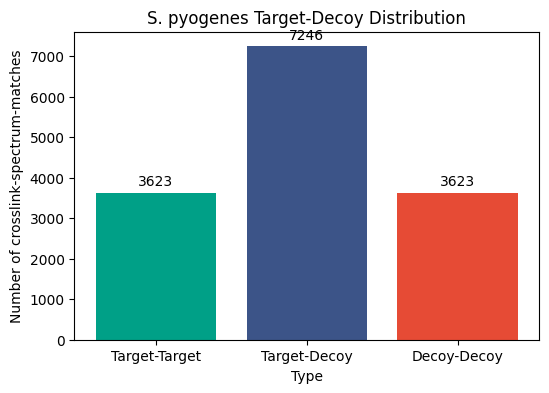

In [10]:
pyXLMS.plotting.plot_target_decoy_distribution(
    spyo_csms,
    figsize=(6, 4),
    title="S. pyogenes Target-Decoy Distribution",
    filename_prefix="plots/spyo_csms_td",
);

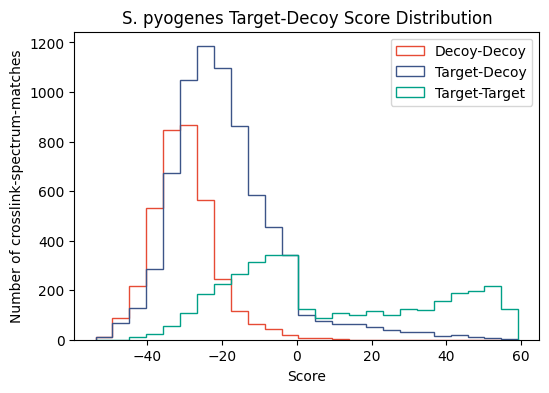

In [11]:
pyXLMS.plotting.plot_score_distribution(
    spyo_csms,
    figsize=(6, 4),
    title="S. pyogenes Target-Decoy Score Distribution",
    filename_prefix="plots/spyo_csms_td_score",
);

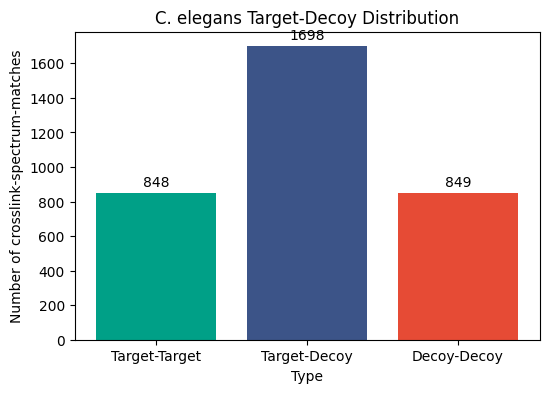

In [12]:
pyXLMS.plotting.plot_target_decoy_distribution(
    cele_csms,
    figsize=(6, 4),
    title="C. elegans Target-Decoy Distribution",
    filename_prefix="plots/cele_csms_td",
);

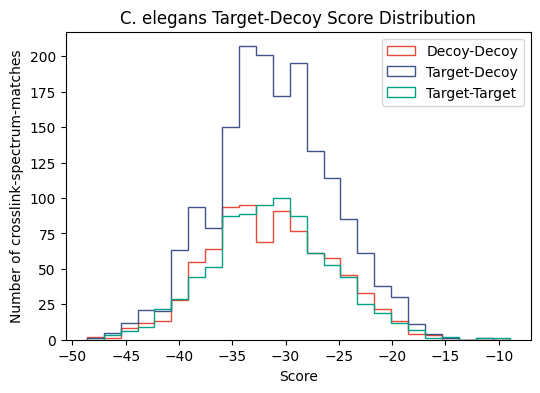

In [13]:
pyXLMS.plotting.plot_score_distribution(
    cele_csms,
    figsize=(6, 4),
    title="C. elegans Target-Decoy Score Distribution",
    filename_prefix="plots/cele_csms_td_score",
);

In [14]:
rescored_level_csm = rescore(df, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 17888 PSMs:
	- Target PSMs: 4472
	- Decoy PSMs: 13416
	- Unique spectra: 17888
	- Unique peptides: 13889
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.Normal

RuntimeError: No PSMs found below the 'eval_fdr' 0.01 for any feature.

In [15]:
rescored_level_csm = rescore(df, level="CSM", use_p_and_q_values=True)

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 17888 PSMs:
	- Target PSMs: 4472
	- Decoy PSMs: 13416
	- Unique spectra: 17888
	- Unique peptides: 13889
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCov

In [16]:
rescored_level_csm_csms = read(rescored_level_csm, score="Mokapot Score")[
    "crosslink-spectrum-matches"
]

Reading CSMs...: 100%|█████████████████████████████████████████████████████████| 17888/17888 [00:05<00:00, 3249.31it/s]


In [17]:
rescored_level_psm = rescore(df, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 35776 PSMs:
	- Target PSMs: 17888
	- Decoy PSMs: 17888
	- Unique spectra: 35776
	- Unique peptides: 1923
	- Features: ('EG.Cscore', 'PP.MatchedIons', 'PP.TotalIons', 'PP.RelativeMatchScore', 'PP.PartialCscore', 'PP.SequenceCoverageNTerm', 'PP.SequenceCoverageCTerm', 'PP.SequenceCoverage', 'PP.UniScore', 'PP.PepLen', 'PP.NumberCrosslinkFragments', 'PP.NormalizedCrosslinkFragments')
INFO:mokapot.brew:Found 35776 total PSMs.
INFO:mokapot.brew:  - 17888 target PSMs and 17888 decoy PSMs detected.
INFO:mokapot.brew:Splitting PSMs into 3 folds...
INFO:mokapot.model:	- Selected feature 'PP.PartialCscore' with 1026 PSMs at q<=0.01.
INFO:mokapot.model:Beginning training loop...
INFO:mokapot.model:Don

In [18]:
rescored_level_psm_csms = read(rescored_level_psm, score="Mokapot Score")[
    "crosslink-spectrum-matches"
]

Reading CSMs...: 100%|█████████████████████████████████████████████████████████| 17888/17888 [00:05<00:00, 3034.78it/s]


In [19]:
def pipeline(csms, fdr: float = 0.01):
    u = pyXLMS.transform.unique(csms)
    v = pyXLMS.transform.validate(u, fdr)
    t = pyXLMS.transform.targets_only(v)
    return t

In [20]:
def get_experimental_fdr(
    csms, true_label="S pyogenes", label_col="PG.Organisms"
) -> Tuple[int, int, float]:
    nr_true = 0
    nr_false = 0
    for csm in csms:
        label = csm["additional_information"]["source"][label_col]
        if label is not None and true_label in label:
            nr_true += 1
        else:
            nr_false += 1
    return nr_true, nr_false, (nr_false / nr_true) * 100.0

### **CSM-level Rescoring**

In [21]:
rescored_target_csm = pipeline(rescored_level_csm_csms)

Iterating over scores for FDR calculation...:  75%|████████████████████▎      | 13416/17888 [00:00<00:00, 36173.97it/s]


In [22]:
nr_true1, nr_false1, efdr1 = get_experimental_fdr(rescored_target_csm)
print(
    f"[CSM-level Rescoring] Number of hits at 1% FDR: {len(rescored_target_csm)}; Number Target Hits: {nr_true1}; Number Entrapment Hits: {nr_false1}; Experimental FDR: {efdr1}%;"
)

[CSM-level Rescoring] Number of hits at 1% FDR: 4472; Number Target Hits: 3623; Number Entrapment Hits: 849; Experimental FDR: 23.433618548164503%;


### **PSM-level Rescoring**

In [23]:
rescored_target_psm = pipeline(rescored_level_psm_csms)

Iterating over scores for FDR calculation...:  95%|█████████████████████████▋ | 17032/17888 [00:00<00:00, 77516.37it/s]


In [24]:
nr_true2, nr_false2, efdr2 = get_experimental_fdr(rescored_target_psm)
print(
    f"[PSM-level Rescoring] Number of hits at 1% FDR: {len(rescored_target_psm)}; Number Target Hits: {nr_true2}; Number Entrapment Hits: {nr_false2}; Experimental FDR: {efdr2}%;"
)

[PSM-level Rescoring] Number of hits at 1% FDR: 848; Number Target Hits: 848; Number Entrapment Hits: 0; Experimental FDR: 0.0%;


### **No Rescoring**

In [25]:
non_rescored_target = pipeline(csms)

Iterating over scores for FDR calculation...:  98%|██████████████████████████▌| 17560/17888 [00:00<00:00, 77978.46it/s]


In [26]:
nr_true3, nr_false3, efdr3 = get_experimental_fdr(non_rescored_target)
print(
    f"[No Rescoring] Number of hits at 1% FDR: {len(non_rescored_target)}; Number Target Hits: {nr_true3}; Number Entrapment Hits: {nr_false3}; Experimental FDR: {efdr3}%;"
)

[No Rescoring] Number of hits at 1% FDR: 325; Number Target Hits: 325; Number Entrapment Hits: 0; Experimental FDR: 0.0%;


In [27]:
def plot_comparison(figsize, filename_prefix=None):
    method = (
        f"No Rescoring\n {efdr3:.2f}% Exp. FDR",
        f"PSM-level Rescoring\n {efdr2:.2f}% Exp. FDR",
        f"CSM-level Rescoring\n {efdr1:.2f}% Exp. FDR",
    )
    counts = {
        "Target": np.array([nr_true3, nr_true2, nr_true1]),
        "Entrapment": np.array([nr_false3, nr_false2, nr_false1]),
    }
    colors = {
        "Target": "#00a087",
        "Entrapment": "#e64b35",
    }
    width = 0.5

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(3)

    for label, count in counts.items():
        p = ax.bar(
            method, count, width, label=label, bottom=bottom, color=colors[label]
        )
        ax.bar_label(p, labels=count, label_type="center")
        bottom += count
    ax.set_xlabel("Rescoring Method")
    ax.set_ylabel("Number of crosslink-spectrum-matches at 1% estimated FDR")
    title = "Number of Target and Entrapment Hits per Rescoring Method"
    ax.legend(loc="upper left")

    if filename_prefix is not None:
        plt.savefig(
            filename_prefix + "_notitle.png",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        plt.savefig(
            filename_prefix + "_notitle.svg",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        ax.set_title(title)
        plt.savefig(
            filename_prefix + ".png", dpi=300, transparent=True, bbox_inches="tight"
        )
        plt.savefig(
            filename_prefix + ".svg", dpi=300, transparent=True, bbox_inches="tight"
        )
    else:
        ax.set_title(title)

    return (fig, ax)

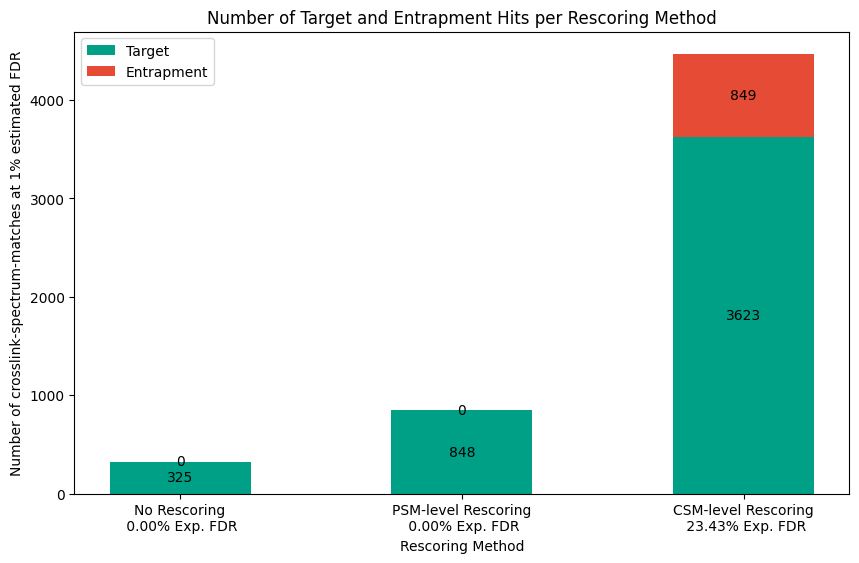

In [28]:
plot_comparison(figsize=(10, 6), filename_prefix="plots/rescoring_method_comparsion");

In [29]:
rescored_level_csm_csms_spyo = list()
rescored_level_csm_csms_cele = list()
for csm in rescored_level_csm_csms:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rescored_level_csm_csms_spyo.append(csm)
    elif label is not None and "Celegans" in label:
        rescored_level_csm_csms_cele.append(csm)

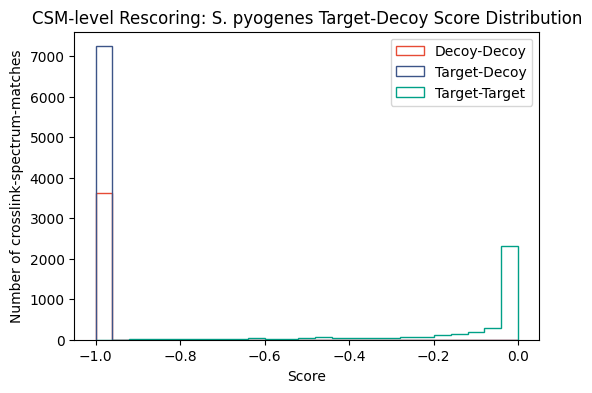

In [30]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_csm_csms_spyo,
    figsize=(6, 4),
    title="CSM-level Rescoring: S. pyogenes Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_csm_csms_spyo_td_score",
);

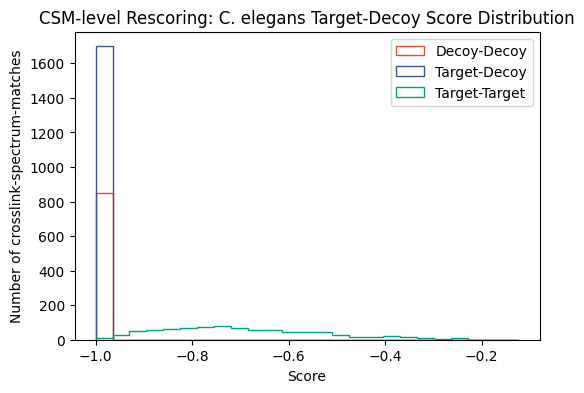

In [31]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_csm_csms_cele,
    figsize=(6, 4),
    title="CSM-level Rescoring: C. elegans Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_csm_csms_cele_td_score",
);

In [32]:
rescored_level_psm_csms_spyo = list()
rescored_level_psm_csms_cele = list()
for csm in rescored_level_psm_csms:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rescored_level_psm_csms_spyo.append(csm)
    elif label is not None and "Celegans" in label:
        rescored_level_psm_csms_cele.append(csm)

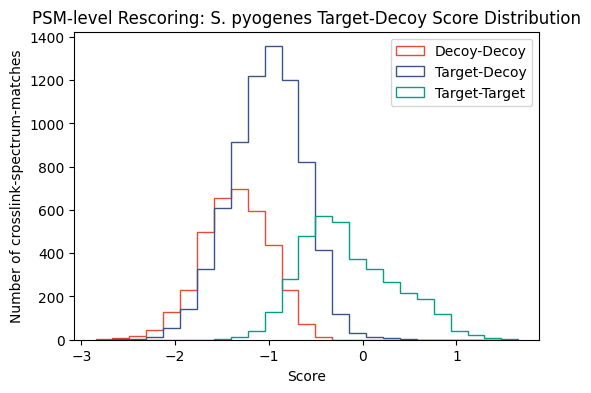

In [33]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_psm_csms_spyo,
    figsize=(6, 4),
    title="PSM-level Rescoring: S. pyogenes Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_psm_csms_spyo_td_score",
);

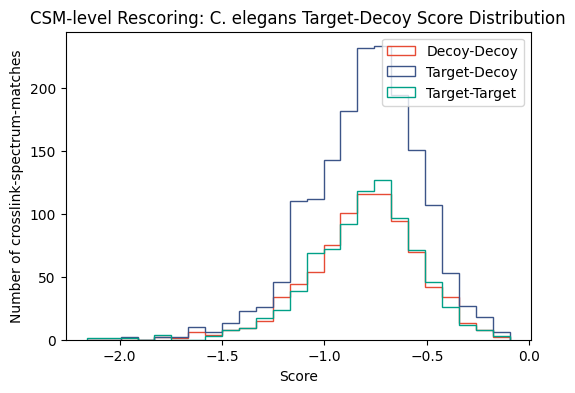

In [34]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_psm_csms_cele,
    figsize=(6, 4),
    title="CSM-level Rescoring: C. elegans Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_psm_csms_cele_td_score",
);

In [35]:
def plot_score_distribution(
    data: List[Dict[str, Any]],
    bins: int = 25,
    density: bool = False,
    colors: List[str] = ["#00a087", "#e64b35"],
    title: str = "Target and Decoy Score Distribution",
    figsize: Tuple[float, float] = (16.0, 9.0),
    filename_prefix: Optional[str] = None,
) -> Tuple[plt.Figure, Any]:
    ylabel = (
        "crosslink-spectrum-matches"
        if data[0]["data_type"] == "crosslink-spectrum-match"
        else "crosslinks"
    )
    filtered = pyXLMS.transform.filter_target_decoy(data)
    tt = [item["score"] for item in filtered["Target-Target"]]
    _td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]

    fig, ax = plt.subplots(figsize=figsize)

    ax.hist(
        [tt, dd],
        bins=bins,
        density=density,
        histtype="step",
        fill=False,
        color=colors,
        label=["Target", "Entrapment"],
    )
    ax.legend(loc="upper right")
    ax.set_ylabel(f"Number of {ylabel}")
    ax.set_xlabel("Score")

    if filename_prefix is not None:
        plt.savefig(
            filename_prefix + "_notitle.png",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        plt.savefig(
            filename_prefix + "_notitle.svg",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        ax.set_title(title)
        plt.savefig(
            filename_prefix + ".png", dpi=300, transparent=True, bbox_inches="tight"
        )
        plt.savefig(
            filename_prefix + ".svg", dpi=300, transparent=True, bbox_inches="tight"
        )
    else:
        ax.set_title(title)

    return (fig, ax)

In [36]:
rescored_level_csm_csms_t = pyXLMS.transform.targets_only(rescored_level_csm_csms)
rescored_level_csm_csms_t = copy.deepcopy(rescored_level_csm_csms_t)
for csm in rescored_level_csm_csms_t:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        csm["alpha_decoy"] = False
        csm["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        csm["alpha_decoy"] = True
        csm["beta_decoy"] = True

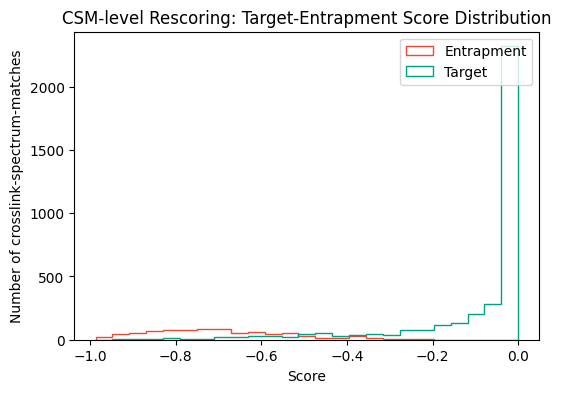

In [37]:
plot_score_distribution(
    rescored_level_csm_csms_t,
    figsize=(6, 4),
    title="CSM-level Rescoring: Target-Entrapment Score Distribution",
    filename_prefix="plots/rescored_level_csm_csms_te_score",
);

In [38]:
rescored_level_psm_csms_t = pyXLMS.transform.targets_only(rescored_level_psm_csms)
rescored_level_psm_csms_t = copy.deepcopy(rescored_level_psm_csms_t)
for csm in rescored_level_psm_csms_t:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        csm["alpha_decoy"] = False
        csm["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        csm["alpha_decoy"] = True
        csm["beta_decoy"] = True

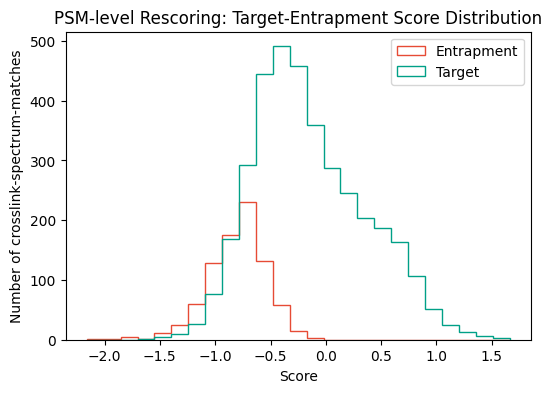

In [39]:
plot_score_distribution(
    rescored_level_psm_csms_t,
    figsize=(6, 4),
    title="PSM-level Rescoring: Target-Entrapment Score Distribution",
    filename_prefix="plots/rescored_level_psm_csms_te_score",
);